# What Drives High Medical Costs?
## Business Problem
A health insurance actuary wants to understand which patient factors 
best predict high medical charges to improve the underwriting model.

**Dataset:** 1,338 patient records | 7 variables  
**Tools:** Python, pandas, seaborn, matplotlib, scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_style("whitegrid")
print("Libraries loaded successfully")


Libraries loaded successfully


In [4]:
df = pd.read_csv('/Users/sumitjha/analytics-portfolio/project-3-insurance-costs/data/insurance.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print("=== Data Types & Nulls ===")
print(df.info())
print("\n=== Statistical Summary ===")
df.describe()


=== Data Types & Nulls ===
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

=== Statistical Summary ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Exploratory Data Analysis
Exploring relationships between patient factors and medical charges.


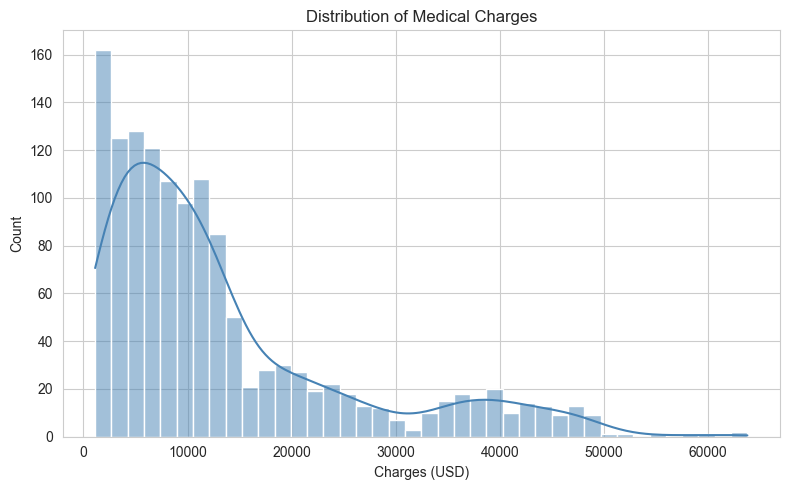

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


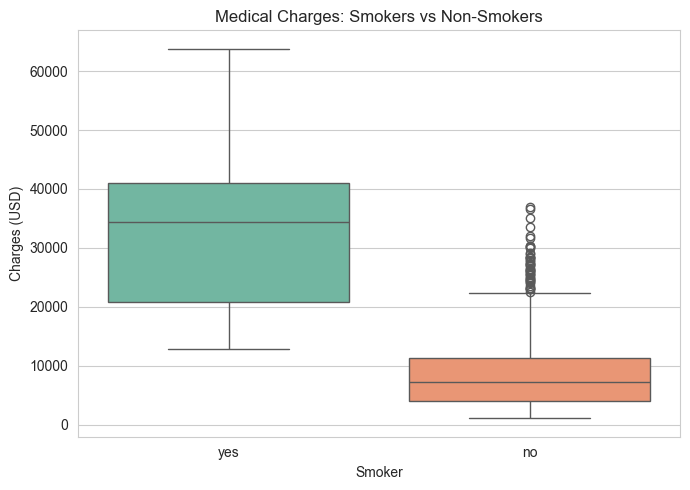

In [10]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='smoker', y='charges', data=df, 
            hue='smoker', legend=False, palette='Set2')
plt.title('Medical Charges: Smokers vs Non-Smokers')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()


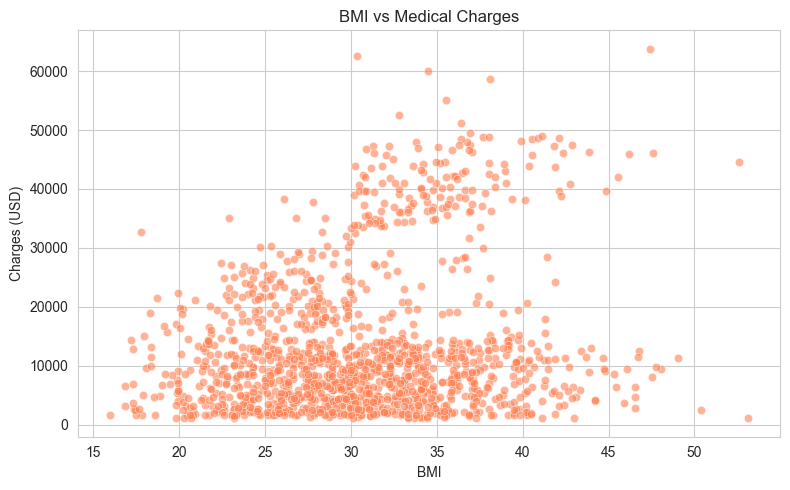

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.6, color='coral')
plt.title('BMI vs Medical Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()


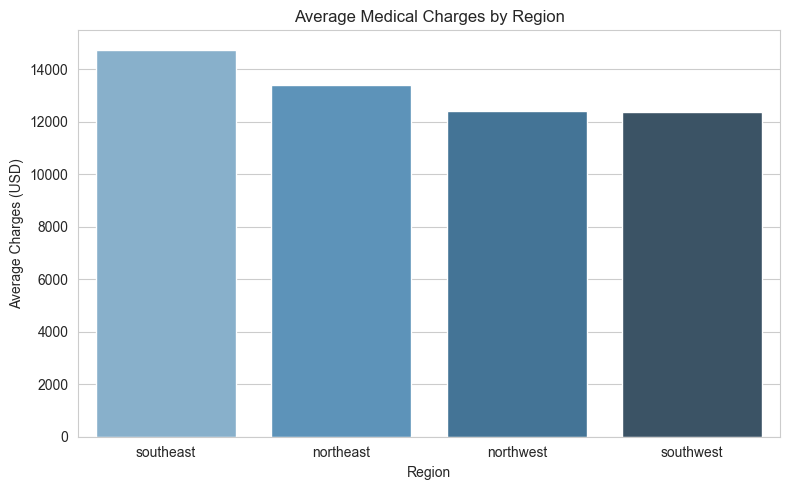

In [11]:
plt.figure(figsize=(8, 5))
region_avg = df.groupby('region')['charges'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='region', y='charges', data=region_avg,
            hue='region', legend=False, palette='Blues_d')
plt.title('Average Medical Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges (USD)')
plt.tight_layout()
plt.show()


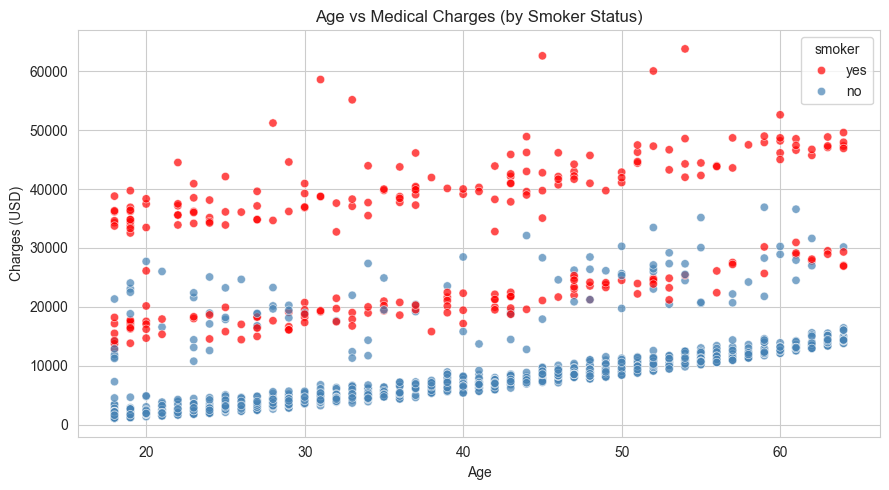

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, 
                palette={'yes': 'red', 'no': 'steelblue'}, alpha=0.7)
plt.title('Age vs Medical Charges (by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()


## Correlation Analysis & Predictive Modeling


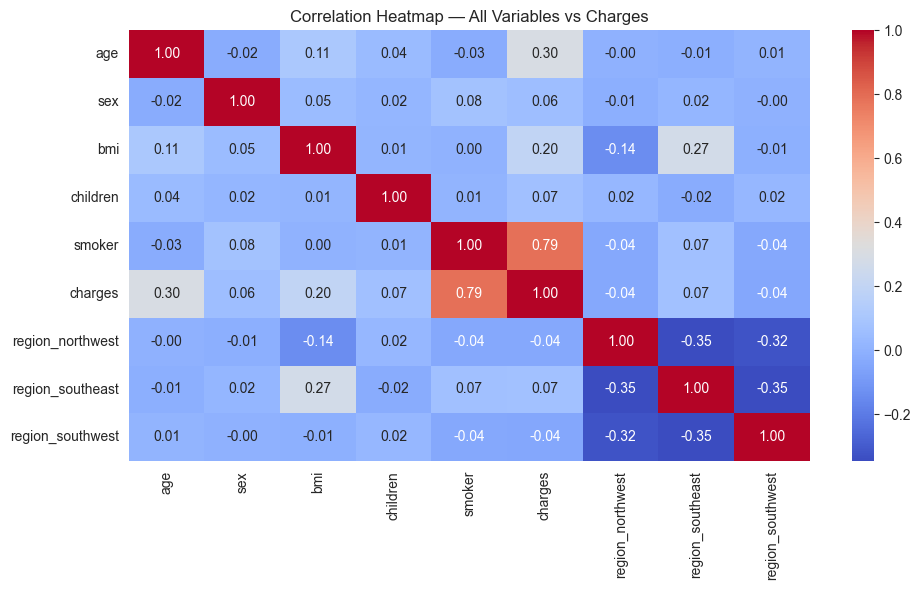

In [13]:
df_encoded = df.copy()
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — All Variables vs Charges')
plt.tight_layout()
plt.show()


In [14]:
X_simple = df_encoded[['smoker']]
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, 
                                                     test_size=0.2, 
                                                     random_state=42)
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
r2_simple = r2_score(y_test, model_simple.predict(X_test))
print(f"Simple Model (smoker only) R² Score: {r2_simple:.4f}")


Simple Model (smoker only) R² Score: 0.6602


In [15]:
X_multi = df_encoded[['age', 'bmi', 'smoker', 'children']]

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, 
                                                     test_size=0.2, 
                                                     random_state=42)
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
r2_multi = r2_score(y_test, model_multi.predict(X_test))
print(f"Multi-Feature Model R² Score: {r2_multi:.4f}")
print(f"\nImprovement over single feature: {r2_multi - r2_simple:.4f}")


Multi-Feature Model R² Score: 0.7811

Improvement over single feature: 0.1209


## Key Findings & Business Recommendations

### What Drives High Medical Costs?
1. **Smoking status** is the single strongest predictor of high charges
   - Smokers pay ~4x more than non-smokers (median $34K vs $7K)
   - Smoking alone explains 66% of charge variation (R² = 0.66)
2. **Age** has a steady positive relationship with charges
   - Both smokers and non-smokers see costs rise consistently with age
3. **BMI** shows elevated charges above the 30 threshold (obese range)
4. **Region** has minimal impact — Southeast slightly higher than others

### Model Performance
| Model | R² Score | Explanation |
|---|---|---|
| Smoker only | 0.66 | 66% of charge variation explained |
| Age + BMI + Smoker + Children | 0.78 | 78% of charge variation explained |

### Recommendations for the Underwriting Team
1. **Flag smoker status** as the highest-risk variable in premium pricing
2. **Apply BMI thresholds** — patients with BMI > 30 warrant higher risk tiers
3. **Age-based tiering** — costs rise predictably with age, supporting stepped premium bands


## Statistical Testing
Testing whether the difference in charges between smokers and 
non-smokers is statistically significant.


In [17]:
from scipy import stats

smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

t_stat, p_value = stats.ttest_ind(smokers, non_smokers)
print(f"Smoker mean charges:     ${smokers.mean():,.2f}")
print(f"Non-smoker mean charges: ${non_smokers.mean():,.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"\nConclusion: {'Statistically significant' if p_value < 0.05 else 'Not significant'} (p < 0.05)")


Smoker mean charges:     $32,050.23
Non-smoker mean charges: $8,434.27
T-statistic: 46.6649
P-value: 0.0000000000

Conclusion: Statistically significant (p < 0.05)


## Model Comparison
Comparing Linear Regression, Ridge Regression, and Random Forest
using 5-fold cross-validation for robust evaluation.


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

X = df_encoded[['age', 'bmi', 'smoker', 'children']]
y = df_encoded['charges']

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_rmse = cross_val_score(model, X, y, cv=5, 
                              scoring='neg_root_mean_squared_error')
    results.append({
        'Model': name,
        'R² (mean)': cv_r2.mean().round(4),
        'R² (std)': cv_r2.std().round(4),
        'RMSE (mean)': abs(cv_rmse.mean()).round(2)
    })

results_df = pd.DataFrame(results)
print("=== 5-Fold Cross-Validation Results ===")
print(results_df.to_string(index=False))


=== 5-Fold Cross-Validation Results ===
            Model  R² (mean)  R² (std)  RMSE (mean)
Linear Regression     0.7469    0.0239      6072.42
 Ridge Regression     0.7469    0.0236      6072.68
    Random Forest     0.8254    0.0305      5025.24


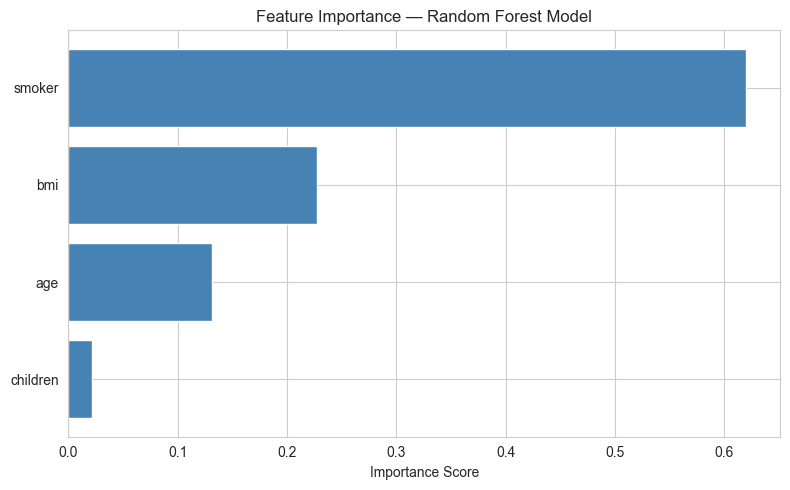

In [19]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'], 
         color='steelblue')
plt.title('Feature Importance — Random Forest Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## Model Selection Summary

| Model | R² (CV) | RMSE |
|---|---|---|
| Linear Regression | 0.7469 | $6,072 |
| Ridge Regression | 0.7469 | $6,072 |
| **Random Forest** | **0.8254** | **$5,025** |

**Winner: Random Forest** — improves R² by 8 points and reduces 
prediction error by $1,047 per patient vs linear models.

### Feature Importance (Random Forest)
- **Smoker: 62%** — dominant predictor
- **BMI: 23%** — elevated risk above threshold 30
- **Age: 13%** — steady cost increase with age
- **Children: 2%** — minimal impact

### Business Recommendations
1. Smoker status must be the primary variable in premium pricing models
2. BMI-based risk tiers (especially above 30) should be implemented
3. Age-stepped premium bands are statistically justified
4. Region and sex can be deprioritized in underwriting models
